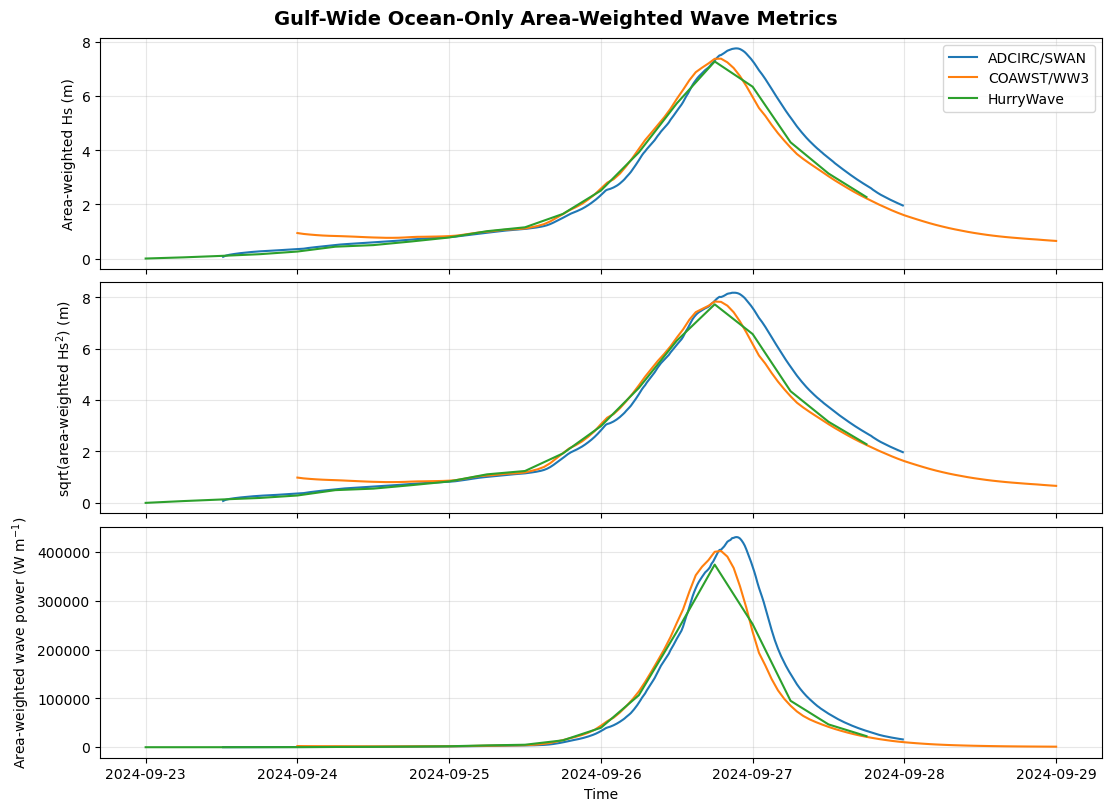

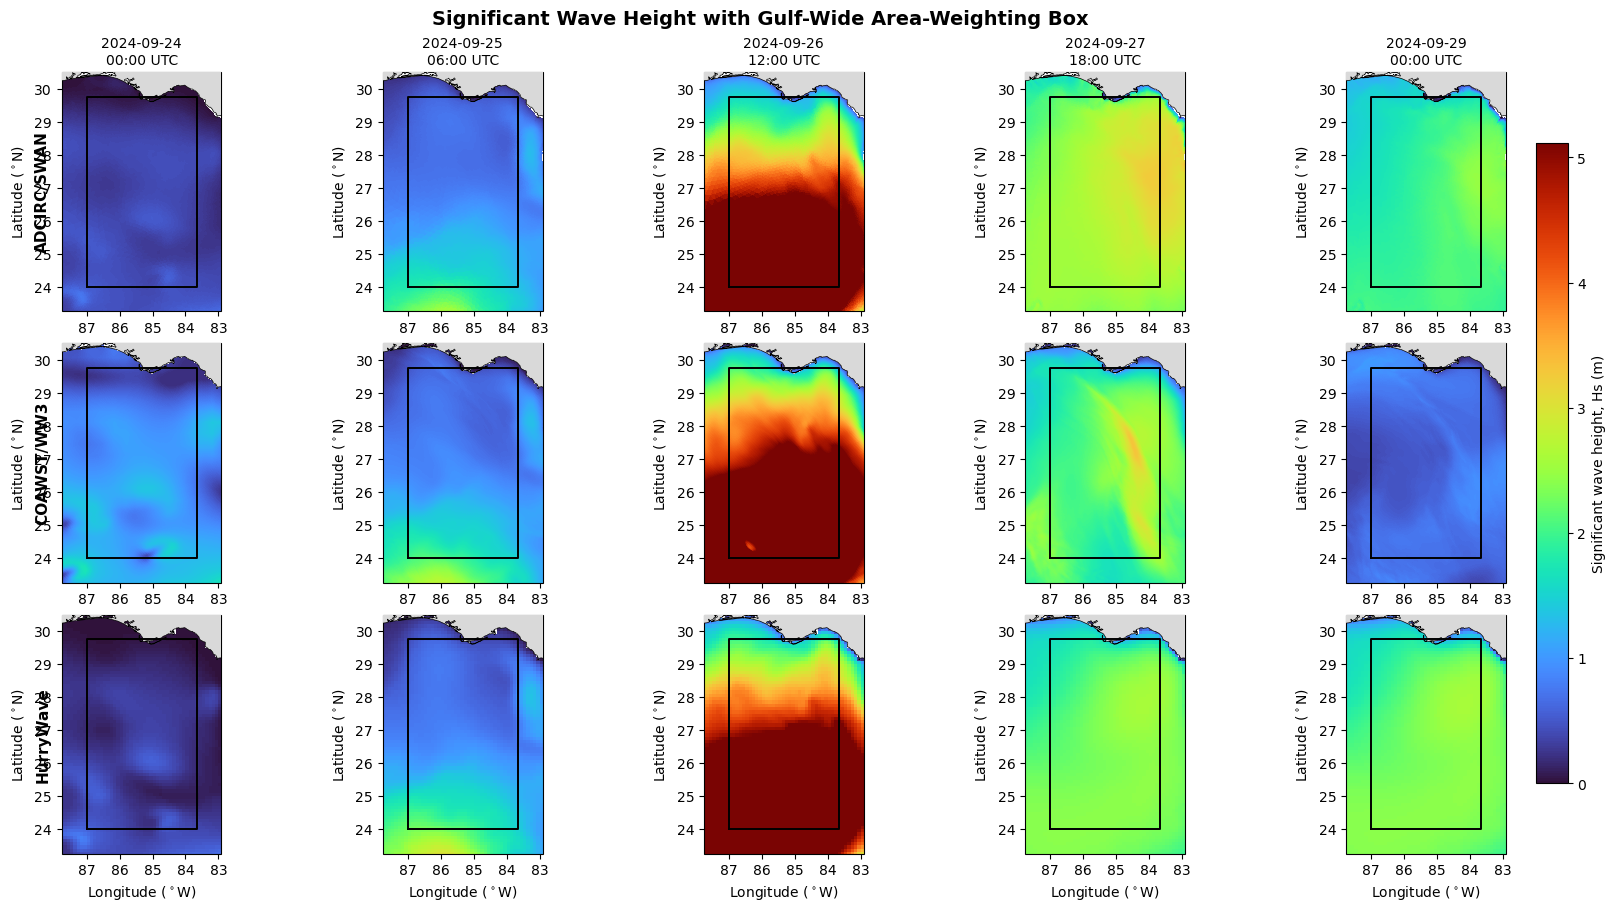

ADCIRC/SWAN:


,time,Hs_a,Hs2_a,Pa,area_sum_Hs_m2,area_sum_P_m2
0,2024-09-23 12:15:00,0.064255,0.073990,3.575087,2.119552e+11,2.001078e+11
1,2024-09-23 12:30:00,0.091066,0.103774,7.918503,2.119540e+11,1.997468e+11
2,2024-09-23 12:45:00,0.111515,0.125657,12.952414,2.119529e+11,1.957444e+11
3,2024-09-23 13:00:00,0.127108,0.141522,17.643846,2.119517e+11,1.956182e+11
4,2024-09-23 13:15:00,0.139360,0.153647,21.332629,2.119509e+11,1.993524e+11


COAWST/WW3:


,time,Hs_a,Hs2_a,Pa,area_sum_Hs_m2,area_sum_P_m2
0,2024-09-24 00:00:00,0.942354,0.984618,2419.386232,2.124032e+11,2.124032e+11
1,2024-09-24 01:00:00,0.908846,0.953416,2286.504630,2.124104e+11,2.124104e+11
2,2024-09-24 02:00:00,0.885984,0.933046,2211.993186,2.124104e+11,2.124104e+11
3,2024-09-24 03:00:00,0.866788,0.916094,2150.393134,2.124104e+11,2.124104e+11
4,2024-09-24 04:00:00,0.851130,0.902385,2101.796029,2.124104e+11,2.124104e+11


HurryWave:


,time,Hs_a,Hs2_a,Pa,area_sum_Hs_m2,area_sum_P_m2
0,2024-09-23 00:00:00,0.000539,0.000539,0.000951,2.102697e+11,2.102697e+11
1,2024-09-23 06:00:00,0.043711,0.070798,7.373884,2.102697e+11,2.102697e+11
2,2024-09-23 12:00:00,0.098146,0.132190,27.876388,2.102697e+11,2.102697e+11
3,2024-09-23 18:00:00,0.159904,0.191202,61.031155,2.102697e+11,2.102697e+11
4,2024-09-24 00:00:00,0.258603,0.287487,148.637872,2.102697e+11,2.102697e+11


In [3]:
# ============================================================
# COMPLETE CELL: VARMAP-BASED AREA-WEIGHTED Hs, Hs2, Pa
# AND 15-PANEL Hs PLOT
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Geod

# ============================================================
# USER FILE PATHS
# ============================================================
HURRYWAVE_FILE = (
    "F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/"
    "helene89pervmax/hurrywave_map.nc"
)

ADCIRC_HS_FILE = (
    "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/"
    "bulk_wave_stats/allnodes_sig_waveheight_ts_swan_HS_63_orig.nc"
)

ADCIRC_TP_FILE = (
    "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/"
    "bulk_wave_stats/allnodes_TPSperiod_ts_swan_TPS_63_orig.nc"
)

COAWST_DAP_URL = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "coawst_gomsab_his.nc"
)

# ============================================================
# STANDARD VARIABLE MAP
# ============================================================
VARMAP = {
    "adcirc": {
        "hs": "swan_HS",
        "tp": "swan_TPS",
        "lon": "x",
        "lat": "y",
        "tri": "element",
        "time": "time",
    },
    "coawst": {
        "hs": "Hwave",
        "tp": "Pwave_top",
        "lon": "lon_rho",
        "lat": "lat_rho",
        "pm": "pm",
        "pn": "pn",
        "time": "ocean_time",
    },
    "hurrywave": {
        "hs": "hm0",
        "tp": "tp",
        "lon": "x",
        "lat": "y",
        "corner_x": "corner_x",
        "corner_y": "corner_y",
        "time": "time",
    },
}

# ============================================================
# SETTINGS
# ============================================================
RHO = 1025.0
G = 9.81

GULF_BOX = {
    "lon_min": -87.00,
    "lon_max": -83.66,
    "lat_min": 24.00,
    "lat_max": 29.75,
}

MODEL_ORDER = ["ADCIRC/SWAN", "COAWST/WW3", "HurryWave"]

PLOT_TIMES = None       # None = 5 equally spaced times from COAWST
CMAP = "turbo"
HS_VMIN = 0.0
HS_VMAX = None          # None = 99th percentile from plotted panels


# ============================================================
# HELPERS
# ============================================================
def fix_adcirc_year_2022_to_2024(t):
    tt = pd.to_datetime(t)
    if np.any(tt.year == 2022):
        tt = tt + pd.DateOffset(years=2)
    return pd.to_datetime(tt)


def wave_power_deepwater(Hs, Tp, rho=RHO, g=G):
    """
    Deep-water wave power per unit crest width.

    P = rho * g^2 / (64*pi) * Hs^2 * Tp

    Units are W/m for Hs in m and Tp in s.
    """
    return rho * g**2 / (64.0 * np.pi) * Hs**2 * Tp


def geodetic_triangle_areas(lon, lat, tri):
    geod = Geod(ellps="WGS84")
    area = np.full(tri.shape[0], np.nan)

    for i, nodes in enumerate(tri):
        a, _ = geod.polygon_area_perimeter(lon[nodes], lat[nodes])
        area[i] = abs(a)

    return area


def element_area_to_node_area(nnode, tri, elem_area):
    node_area = np.zeros(nnode, dtype=float)

    for k in range(3):
        np.add.at(node_area, tri[:, k], elem_area / 3.0)

    return node_area


def hurrywave_cell_areas_from_corners(corner_x, corner_y):
    geod = Geod(ellps="WGS84")

    if corner_x.shape[-1] != 4:
        raise ValueError("Expected corner_x/corner_y last dimension to have length 4.")

    area = np.full(corner_x.shape[:-1], np.nan)

    it = np.nditer(area, flags=["multi_index"], op_flags=["readwrite"])
    for a in it:
        idx = it.multi_index
        lons = corner_x[idx]
        lats = corner_y[idx]

        if np.all(np.isfinite(lons)) and np.all(np.isfinite(lats)):
            aa, _ = geod.polygon_area_perimeter(lons, lats)
            a[...] = abs(aa)

    return area


def coawst_cell_area(pm, pn):
    return 1.0 / (pm * pn)


def nearest_time_index(time, target_time):
    time = pd.to_datetime(time)
    target_time = pd.Timestamp(target_time)
    return int(np.argmin(np.abs(time - target_time)))


def area_weighted_timeseries(Hs, Tp, area, lon, lat, time, box=GULF_BOX):
    Hs = np.asarray(Hs, dtype=float)
    Tp = np.asarray(Tp, dtype=float)
    area = np.asarray(area, dtype=float)
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)

    in_box = (
        (lon >= box["lon_min"]) &
        (lon <= box["lon_max"]) &
        (lat >= box["lat_min"]) &
        (lat <= box["lat_max"])
    )

    P = wave_power_deepwater(Hs, Tp)

    nt = Hs.shape[0]

    Hs_a = np.full(nt, np.nan)
    Hs2_a = np.full(nt, np.nan)
    Pa = np.full(nt, np.nan)
    area_sum_Hs = np.full(nt, np.nan)
    area_sum_P = np.full(nt, np.nan)

    for it in range(nt):
        valid_hs = in_box & np.isfinite(Hs[it])
        valid_p = in_box & np.isfinite(P[it])

        A_hs = np.where(valid_hs, area, np.nan)
        A_p = np.where(valid_p, area, np.nan)

        area_sum_Hs[it] = np.nansum(A_hs)
        area_sum_P[it] = np.nansum(A_p)

        if area_sum_Hs[it] > 0:
            Hs_a[it] = np.nansum(Hs[it] * A_hs) / area_sum_Hs[it]
            Hs2_a[it] = np.sqrt(np.nansum(Hs[it]**2 * A_hs) / area_sum_Hs[it])

        if area_sum_P[it] > 0:
            Pa[it] = np.nansum(P[it] * A_p) / area_sum_P[it]

    return pd.DataFrame(
        {
            "time": pd.to_datetime(time),
            "Hs_a": Hs_a,
            "Hs2_a": Hs2_a,
            "Pa": Pa,
            "area_sum_Hs_m2": area_sum_Hs,
            "area_sum_P_m2": area_sum_P,
        }
    )


# ============================================================
# OPEN DATASETS
# ============================================================
def open_hurrywave_dataset():
    return xr.open_dataset(HURRYWAVE_FILE)


def open_adcirc_hs_dataset():
    return xr.open_dataset(ADCIRC_HS_FILE)


def open_adcirc_tp_dataset():
    return xr.open_dataset(ADCIRC_TP_FILE)


def open_coawst_dataset():
    return xr.open_dataset(COAWST_DAP_URL, engine="netcdf4")


# ============================================================
# PREPARE INPUTS
# ============================================================
def hurrywave_cell_areas_from_corners(corner_x, corner_y, x=None, y=None):
    """
    Compute HurryWave cell areas from corner lon/lat arrays.

    Handles:
        1) corner_x shape (ny, nx, 4)
        2) corner_x shape (4, ny, nx)
        3) corner_x shape (ny+1, nx+1), i.e. 2-D corner-node grid

    Returns area in m^2.

    If x/y are supplied, the returned area is trimmed/padded as needed to
    match x.shape.
    """
    geod = Geod(ellps="WGS84")

    corner_x = np.asarray(corner_x)
    corner_y = np.asarray(corner_y)

    # --------------------------------------------------------
    # Case 1 or 2: explicit 4 corners per cell
    # --------------------------------------------------------
    if corner_x.ndim == 3:
        if corner_x.shape[-1] == 4:
            cx = corner_x
            cy = corner_y
        elif corner_x.shape[0] == 4:
            cx = np.moveaxis(corner_x, 0, -1)
            cy = np.moveaxis(corner_y, 0, -1)
        else:
            raise ValueError(f"Unrecognized 3-D corner shape: {corner_x.shape}")

        area = np.full(cx.shape[:-1], np.nan)

        it = np.nditer(area, flags=["multi_index"], op_flags=["readwrite"])
        for a in it:
            idx = it.multi_index
            lons = cx[idx]
            lats = cy[idx]

            if np.all(np.isfinite(lons)) and np.all(np.isfinite(lats)):
                aa, _ = geod.polygon_area_perimeter(lons, lats)
                a[...] = abs(aa)

    # --------------------------------------------------------
    # Case 3: 2-D corner-node grid
    # --------------------------------------------------------
    elif corner_x.ndim == 2:
        nyc, nxc = corner_x.shape
        area = np.full((nyc - 1, nxc - 1), np.nan)

        for j in range(nyc - 1):
            for i in range(nxc - 1):
                lons = np.array([
                    corner_x[j, i],
                    corner_x[j, i + 1],
                    corner_x[j + 1, i + 1],
                    corner_x[j + 1, i],
                ])

                lats = np.array([
                    corner_y[j, i],
                    corner_y[j, i + 1],
                    corner_y[j + 1, i + 1],
                    corner_y[j + 1, i],
                ])

                if np.all(np.isfinite(lons)) and np.all(np.isfinite(lats)):
                    aa, _ = geod.polygon_area_perimeter(lons, lats)
                    area[j, i] = abs(aa)

    else:
        raise ValueError(f"Unrecognized corner_x shape: {corner_x.shape}")

    # --------------------------------------------------------
    # Align to x/y grid shape if needed
    # --------------------------------------------------------
    if x is not None:
        target_shape = np.asarray(x).shape

        if area.shape != target_shape:
            area2 = np.full(target_shape, np.nan)

            ny = min(area.shape[0], target_shape[0])
            nx = min(area.shape[1], target_shape[1])

            area2[:ny, :nx] = area[:ny, :nx]
            area = area2

    return area

def prepare_hurrywave_inputs(ds_hw):
    v = VARMAP["hurrywave"]

    hs_hw = ds_hw[v["hs"]].values
    tp_hw = ds_hw[v["tp"]].values
    x_hw = ds_hw[v["lon"]].values
    y_hw = ds_hw[v["lat"]].values
    corner_x_hw = ds_hw[v["corner_x"]].values
    corner_y_hw = ds_hw[v["corner_y"]].values
    time_hw = pd.to_datetime(ds_hw[v["time"]].values)

    mask_hw = None
    if "msk" in ds_hw:
        mask_hw = np.asarray(ds_hw["msk"].values) > 0
        hs_hw = np.where(mask_hw[None, :, :], hs_hw, np.nan)
        tp_hw = np.where(mask_hw[None, :, :], tp_hw, np.nan)

    area_hw = hurrywave_cell_areas_from_corners(
        corner_x_hw,
        corner_y_hw,
        x=x_hw,
        y=y_hw,
    )

    return hs_hw, tp_hw, x_hw, y_hw, area_hw, corner_x_hw, corner_y_hw, time_hw, mask_hw


def prepare_adcirc_inputs(ds_adc_hs, ds_adc_tp):
    v = VARMAP["adcirc"]

    hs_adc = ds_adc_hs[v["hs"]].values
    tp_adc = ds_adc_tp[v["tp"]].values

    lon_adc = ds_adc_hs[v["lon"]].values
    lat_adc = ds_adc_hs[v["lat"]].values
    time_adc = fix_adcirc_year_2022_to_2024(ds_adc_hs[v["time"]].values)

    tri_adc = ds_adc_hs[v["tri"]].values.astype(int)
    start_index = ds_adc_hs[v["tri"]].attrs.get("start_index", None)

    if start_index == 1 or tri_adc.min() == 1:
        tri_adc = tri_adc - 1

    elem_area_adc = geodetic_triangle_areas(lon_adc, lat_adc, tri_adc)
    area_adc = element_area_to_node_area(len(lon_adc), tri_adc, elem_area_adc)

    return hs_adc, tp_adc, lon_adc, lat_adc, tri_adc, area_adc, time_adc


def prepare_coawst_inputs(ds_cw):
    v = VARMAP["coawst"]

    hs_cw = ds_cw[v["hs"]].values
    tp_cw = ds_cw[v["tp"]].values

    lon_rho = ds_cw[v["lon"]].values
    lat_rho = ds_cw[v["lat"]].values
    pm = ds_cw[v["pm"]].values
    pn = ds_cw[v["pn"]].values
    time_cw = pd.to_datetime(ds_cw[v["time"]].values)

    if "wetdry_mask_rho" in ds_cw:
        wet = np.asarray(ds_cw["wetdry_mask_rho"].values) > 0
        hs_cw = np.where(wet, hs_cw, np.nan)
        tp_cw = np.where(wet, tp_cw, np.nan)

    if "mask_rho" in ds_cw:
        mask_rho = np.asarray(ds_cw["mask_rho"].values) > 0
        hs_cw = np.where(mask_rho[None, :, :], hs_cw, np.nan)
        tp_cw = np.where(mask_rho[None, :, :], tp_cw, np.nan)

    area_cw = coawst_cell_area(pm, pn)

    return hs_cw, tp_cw, lon_rho, lat_rho, pm, pn, area_cw, time_cw


# ============================================================
# PLOTTING HELPERS
# ============================================================
def add_gulf_box(ax, box=GULF_BOX):
    x0, x1 = box["lon_min"], box["lon_max"]
    y0, y1 = box["lat_min"], box["lat_max"]

    ax.plot(
        [x0, x1, x1, x0, x0],
        [y0, y0, y1, y1, y0],
        transform=ccrs.PlateCarree(),
        color="k",
        linewidth=1.4,
        linestyle="-",
        zorder=20,
    )


def set_map_ticks(ax, extent):
    lon_min, lon_max, lat_min, lat_max = extent

    lon_ticks = np.arange(np.ceil(lon_min), np.floor(lon_max) + 1, 1)
    lat_ticks = np.arange(np.ceil(lat_min), np.floor(lat_max) + 1, 1)

    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    ax.set_xticklabels([f"{abs(x):.0f}" for x in lon_ticks])
    ax.set_yticklabels([f"{y:.0f}" for y in lat_ticks])


def plot_hs_panel(ax, model_name, it, plot_data, vmin=HS_VMIN, vmax=HS_VMAX):
    if model_name == "ADCIRC/SWAN":
        hs = plot_data["adc"]["hs"][it, :]
        lon = plot_data["adc"]["lon"]
        lat = plot_data["adc"]["lat"]
        tri = plot_data["adc"]["tri"]

        triang = mtri.Triangulation(lon, lat, tri)

        h = ax.tripcolor(
            triang,
            hs,
            shading="flat",
            cmap=CMAP,
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
        )

    elif model_name == "COAWST/WW3":
        hs = plot_data["cw"]["hs"][it, :, :]
        lon = plot_data["cw"]["lon"]
        lat = plot_data["cw"]["lat"]

        h = ax.pcolormesh(
            lon,
            lat,
            hs,
            shading="auto",
            cmap=CMAP,
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
        )

    elif model_name == "HurryWave":
        hs = plot_data["hw"]["hs"][it, :, :]
        lon = plot_data["hw"]["lon"]
        lat = plot_data["hw"]["lat"]

        h = ax.pcolormesh(
            lon,
            lat,
            hs,
            shading="auto",
            cmap=CMAP,
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
        )

    else:
        raise ValueError(model_name)

    return h


def make_15_panel_hs_plot(plot_data, plot_times=None, box=GULF_BOX):
    if plot_times is None:
        time_ref = plot_data["cw"]["time"]
        ii = np.linspace(0, len(time_ref) - 1, 5).astype(int)
        plot_times = time_ref[ii]

    plot_times = pd.to_datetime(plot_times)

    idx = {
        "ADCIRC/SWAN": [nearest_time_index(plot_data["adc"]["time"], t) for t in plot_times],
        "COAWST/WW3": [nearest_time_index(plot_data["cw"]["time"], t) for t in plot_times],
        "HurryWave": [nearest_time_index(plot_data["hw"]["time"], t) for t in plot_times],
    }

    extent = [
        box["lon_min"] - 0.75,
        box["lon_max"] + 0.75,
        box["lat_min"] - 0.75,
        box["lat_max"] + 0.75,
    ]

    if HS_VMAX is None:
        vals = []
        for model_name in MODEL_ORDER:
            for k in idx[model_name]:
                if model_name == "ADCIRC/SWAN":
                    vals.append(plot_data["adc"]["hs"][k, :])
                elif model_name == "COAWST/WW3":
                    vals.append(plot_data["cw"]["hs"][k, :, :])
                elif model_name == "HurryWave":
                    vals.append(plot_data["hw"]["hs"][k, :, :])

        vmax = np.nanpercentile(np.concatenate([v.ravel() for v in vals]), 99)
    else:
        vmax = HS_VMAX

    fig, axes = plt.subplots(
        3,
        5,
        figsize=(17, 9),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    last_h = None

    for irow, model_name in enumerate(MODEL_ORDER):
        for icol, t in enumerate(plot_times):
            ax = axes[irow, icol]

            this_it = idx[model_name][icol]

            last_h = plot_hs_panel(
                ax,
                model_name,
                this_it,
                plot_data,
                vmin=HS_VMIN,
                vmax=vmax,
            )

            ax.set_extent(extent, crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=10)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=11)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=11)

            add_gulf_box(ax, box=box)
            set_map_ticks(ax, extent)

            # Latitude ticks intentionally shown on every panel.
            ax.set_ylabel("Latitude ($^\\circ$N)", labelpad=6)

            if irow == 2:
                ax.set_xlabel("Longitude ($^\\circ$W)")
            else:
                ax.set_xlabel("")

            if irow == 0:
                ax.set_title(
                    pd.Timestamp(t).strftime("%Y-%m-%d\n%H:%M UTC"),
                    fontsize=10,
                )

            if icol == 0:
                ax.text(
                    -0.12,
                    0.5,
                    model_name,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=11,
                    fontweight="bold",
                )

    cbar = fig.colorbar(last_h, ax=axes.ravel().tolist(), shrink=0.82, pad=0.015)
    cbar.set_label("Significant wave height, Hs (m)")

    fig.suptitle(
        "Significant Wave Height with Gulf-Wide Area-Weighting Box",
        fontsize=14,
        fontweight="bold",
    )

    return fig, axes


def plot_area_weighted_timeseries(df_adc, df_cw, df_hw):
    dutch_orange = '#F36C21'
    unc_blue = '#4B9CD3'
    usgs_green = '#2E8B57'

    colors = [ unc_blue, usgs_green, dutch_orange ]
    
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(11, 8),
        sharex=True,
        constrained_layout=True,
    )

    series = [
        ("Hs_a", "Area-weighted Hs (m)"),
        ("Hs2_a", "sqrt(area-weighted Hs$^2$) (m)"),
        ("Pa", "Area-weighted wave power (W m$^{-1}$)"),
    ]

    for ax, (var, label) in zip(axes, series):
        ax.plot(df_adc["time"], df_adc[var], c=colors[0], lw=2, label="ADCIRC/SWAN")
        ax.plot(df_cw["time"], df_cw[var], c=colors[1], lw=2, label="COAWST/WW3")
        ax.plot(df_hw["time"], df_hw[var], c=colors[2], lw=2label="HurryWave")

        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc="best")
    axes[-1].set_xlabel("Time")

    fig.suptitle(
        "Gulf-Wide Ocean-Only Area-Weighted Wave Metrics",
        fontsize=14,
        fontweight="bold",
    )

    return fig, axes


# ============================================================
# RUN
# ============================================================
ds_hw = open_hurrywave_dataset()
ds_adc_hs = open_adcirc_hs_dataset()
ds_adc_tp = open_adcirc_tp_dataset()
ds_cw = open_coawst_dataset()

hs_hw, tp_hw, x_hw, y_hw, area_hw, corner_x_hw, corner_y_hw, time_hw, mask_hw = prepare_hurrywave_inputs(ds_hw)


hs_adc, tp_adc, lon_adc, lat_adc, tri_adc, area_adc, time_adc = prepare_adcirc_inputs(
    ds_adc_hs,
    ds_adc_tp,
)

hs_cw, tp_cw, lon_rho, lat_rho, pm, pn, area_cw, time_cw = prepare_coawst_inputs(ds_cw)

df_adc = area_weighted_timeseries(
    hs_adc,
    tp_adc,
    area_adc,
    lon_adc,
    lat_adc,
    time_adc,
    box=GULF_BOX,
)

df_cw = area_weighted_timeseries(
    hs_cw,
    tp_cw,
    area_cw,
    lon_rho,
    lat_rho,
    time_cw,
    box=GULF_BOX,
)

df_hw = area_weighted_timeseries(
    hs_hw,
    tp_hw,
    area_hw,
    x_hw,
    y_hw,
    time_hw,
    box=GULF_BOX,
)

plot_data = {
    "adc": {
        "hs": hs_adc,
        "tp": tp_adc,
        "lon": lon_adc,
        "lat": lat_adc,
        "tri": tri_adc,
        "area": area_adc,
        "time": time_adc,
        "df": df_adc,
    },
    "cw": {
        "hs": hs_cw,
        "tp": tp_cw,
        "lon": lon_rho,
        "lat": lat_rho,
        "area": area_cw,
        "time": time_cw,
        "df": df_cw,
    },
    "hw": {
        "hs": hs_hw,
        "tp": tp_hw,
        "lon": x_hw,
        "lat": y_hw,
        "area": area_hw,
        "time": time_hw,
        "df": df_hw,
    },
}

fig_ts, axes_ts = plot_area_weighted_timeseries(df_adc, df_cw, df_hw)
plt.show()

fig_15, axes_15 = make_15_panel_hs_plot(
    plot_data,
    plot_times=PLOT_TIMES,
    box=GULF_BOX,
)
plt.show()

print("ADCIRC/SWAN:")
display(df_adc.head())

print("COAWST/WW3:")
display(df_cw.head())

print("HurryWave:")
display(df_hw.head())

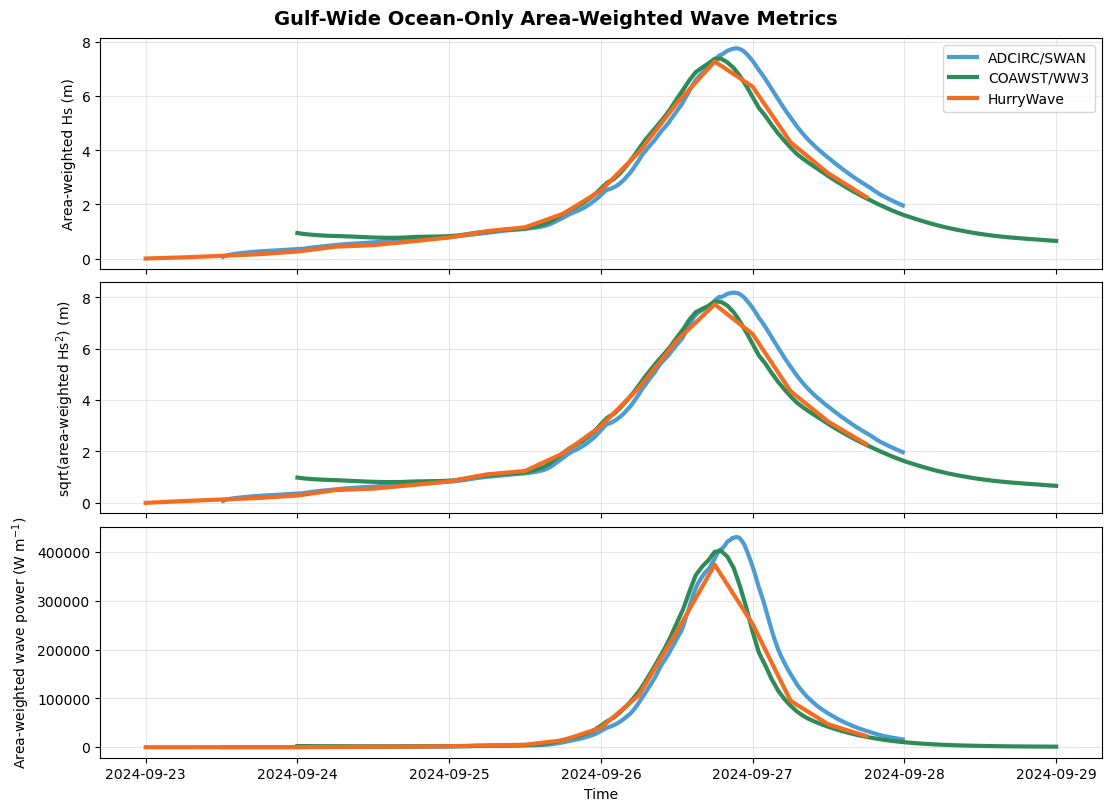

In [6]:
def plot_area_weighted_timeseries(df_adc, df_cw, df_hw):
    dutch_orange = '#F36C21'
    unc_blue = '#4B9CD3'
    usgs_green = '#2E8B57'

    colors = [ unc_blue, usgs_green, dutch_orange ]
    
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(11, 8),
        sharex=True,
        constrained_layout=True,
    )

    series = [
        ("Hs_a", "Area-weighted Hs (m)"),
        ("Hs2_a", "sqrt(area-weighted Hs$^2$) (m)"),
        ("Pa", "Area-weighted wave power (W m$^{-1}$)"),
    ]

    for ax, (var, label) in zip(axes, series):
        ax.plot(df_adc["time"], df_adc[var], c=colors[0], lw=3, label="ADCIRC/SWAN")
        ax.plot(df_cw["time"], df_cw[var], c=colors[1], lw=3, label="COAWST/WW3")
        ax.plot(df_hw["time"], df_hw[var], c=colors[2], lw=3, label="HurryWave")

        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc="best")
    axes[-1].set_xlabel("Time")

    fig.suptitle(
        "Gulf-Wide Ocean-Only Area-Weighted Wave Metrics",
        fontsize=14,
        fontweight="bold",
    )

    return fig, axes

fig_ts, axes_ts = plot_area_weighted_timeseries(df_adc, df_cw, df_hw)
plt.savefig( "F:/crs/proj/2025_NOPP_comparison/helene_figs/gulf_wide_area_weighted_metrics.png")
plt.show()